In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [1]:
hg002_adaptive_region_df = pd.read_csv("HG002_adaptive_region_methylation.bed.gz", sep="\t", header=None)
hg002_adaptive_wg_df = pd.read_csv("HG002_adaptive_wg_methylation.bed.gz", sep="\t", )
hg002_wgs_wg_df = pd.read_csv("HG002_wgs_wg_methylation.bed.gz", sep="\t",)
hg002_individual_wgs_wg_df = pd.read_csv("HG002_individual_wgs_wg_methylation.bed.gz", sep="\t", header=None)


KeyboardInterrupt

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x733a96eaee40>>
Traceback (most recent call last):
  File "/home/yilei/micromamba/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
df1 = hg002_adaptive_region_df
df2 = hg002_adaptive_wg_df
df3 = hg002_wgs_wg_df
df4 = hg002_individual_wgs_wg_df

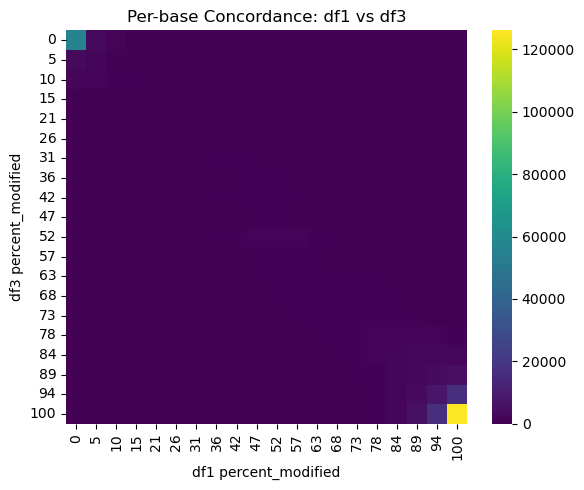

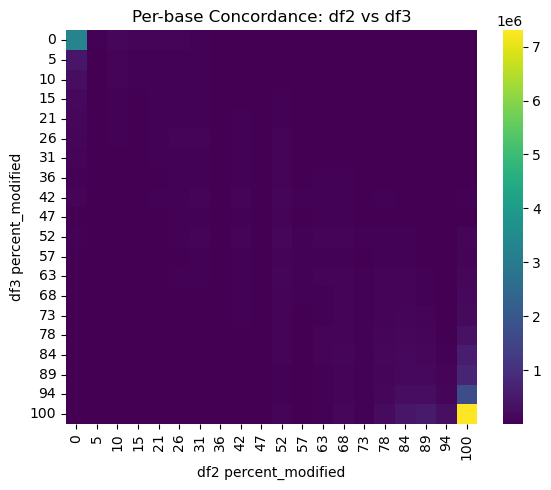

In [19]:
def key(df):
    return df["#chrom"].astype(str) + ":" + df["chromStart"].astype(str)
df1.columns = df2.columns
df4.columns = df2.columns
df1["key"] = key(df1)
df2["key"] = key(df2)
df3["key"] = key(df3)
df4["key"] = key(df4)

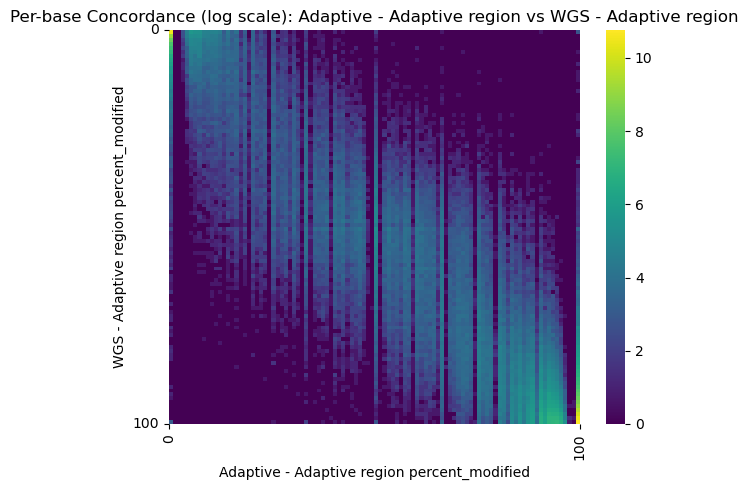

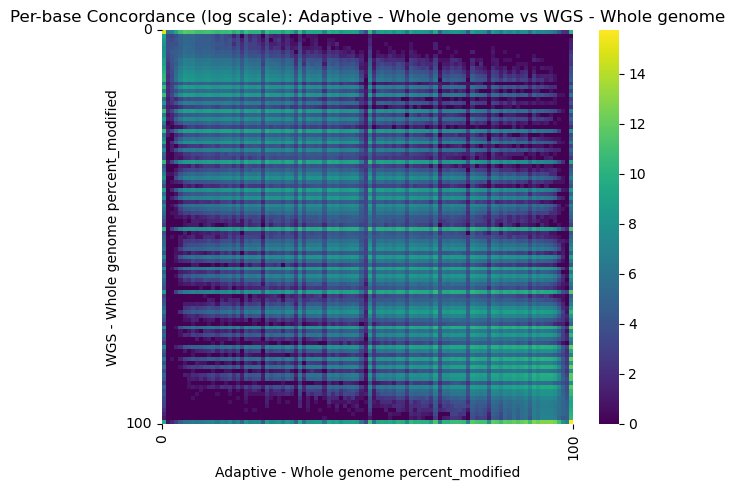

In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_concordance_heatmap(dfA, nameA, dfB, nameB, bins=20):
    merged = dfA[["key", "percent_modified"]].merge(
        dfB[["key", "percent_modified"]], on="key", suffixes=(f"_{nameA}", f"_{nameB}")
    )

    x = merged[f"percent_modified_{nameA}"]
    y = merged[f"percent_modified_{nameB}"]

    # 2D histogram for density
    heatmap, xedges, yedges = np.histogram2d(
        x, y, bins=bins, range=[[0, 100], [0, 100]]
    )

    # Apply log scale
    heatmap_log = np.log1p(heatmap)  # log(1+x)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        heatmap_log,
        xticklabels=np.linspace(0, 100, bins, dtype=int),
        yticklabels=np.linspace(0, 100, bins, dtype=int),
        cmap="viridis"
    )
    plt.xlabel(f"{nameA} percent_modified")
    plt.ylabel(f"{nameB} percent_modified")
    plt.title(f"Per-base Concordance (log scale): {nameA} vs {nameB}")

    # Only mark 0 and 100 on axes
    plt.xticks([0, bins], [0, 100])
    plt.yticks([0, bins], [0, 100])

    plt.tight_layout()
    plt.show()

plot_concordance_heatmap(df1, "Adaptive - Adaptive region", df3, "WGS - Adaptive region", bins=100)
plot_concordance_heatmap(df2, "Adaptive - Whole genome", df3, "WGS - Whole genome", bins=100)

In [35]:
import numpy as np

def compute_concordance(dfA, nameA, dfB, nameB, tolerance=20):
    merged = dfA[["key", "percent_modified"]].merge(
        dfB[["key", "percent_modified"]],
        on="key",
        suffixes=(f"_{nameA}", f"_{nameB}")
    )

    x = merged[f"percent_modified_{nameA}"].to_numpy()
    y = merged[f"percent_modified_{nameB}"].to_numpy()

    concordant = np.abs(x - y) <= tolerance
    concordance_rate = concordant.sum() / len(concordant)

    return concordance_rate
rate1 = compute_concordance(df1, "Adaptive-Region", df3, "WGS-Region", tolerance=20)
rate2 = compute_concordance(df2, "Adaptive-WGS", df3, "WGS-WGS", tolerance=20)

In [36]:
print("Rate1:", rate1)
print("Rate2:", rate2)

Rate1: 0.9478295118863412
Rate2: 0.8137766217791117
